# Factor Analysis and Diagnostics

## Purpose

A **factor** or **signal** is a vector of scores for the stocks available at a date:

$$f_t \in \mathbb{R}^{N_t}.$$

The question in this notebook is simple: when we rank stocks by $f_t$, do the higher-ranked stocks tend to have better subsequent returns?

In practice we measure this with the **information coefficient (IC)**, a Spearman rank correlation. After ranks are centered, a correlation is also a cosine similarity:

$$\rho(u,v)=\frac{\langle u,v\rangle}{\|u\|\|v\|}=\cos\theta.$$

So the IC is a geometric question: does the signal vector point roughly in the same direction as the return vector?

We test four common factor ideas using data we can build from prices alone:
1. Momentum
2. A crude value proxy
3. A crude quality proxy
4. Low volatility

Momentum is the only one that looks useful in this dataset. That is not a universal statement about factor investing; it mostly tells us that the other three proxies are too crude for this public-price-only setup.

### Timing convention

The raw factor formulas use `.shift(1)`, so the score at a given return date is based only on information available before that return was realized. That is why the IC code can pair `factor.loc[date]` with `returns.loc[date]` without looking ahead.

## Terms used

| Term | Meaning |
|------|---------|
| **Factor / signal** | A vector $f_t \in \mathbb{R}^{N_t}$ assigning one score per stock |
| **Momentum** | Trailing 12-1 return: recent winners may keep winning |
| **Value** | Cheap stocks may outperform; here proxied crudely by inverse long-term return |
| **Quality** | Profitable/stable firms may outperform; here proxied by a rolling Sharpe-like ratio |
| **Low volatility** | Lower-risk stocks may outperform on a risk-adjusted basis |
| **Information coefficient (IC)** | Spearman rank correlation between signal ranks and subsequent return ranks |
| **Information ratio (IR)** | Mean IC / std(IC), annualized here by $\sqrt{12}$ |
| **Rank** | Cross-sectional ordering of stocks; useful because it is robust to outliers |
| **Turnover proxy** | How much the signal changes; here approximated with rank autocorrelation |
| **Walk-forward** | Split into subperiods to see whether a result is stable across regimes |
| **Return panel** $R$ ↻ | The monthly return matrix from notebook 01 |

## Outputs

This notebook writes factor exposure CSVs, monthly IC series, IC decay, subperiod diagnostics, and a cross-factor correlation matrix.

## Notebook Structure
1. [Setup and Imports](#setup-and-imports)
2. [Load Data](#load-data)
3. [Factor Definitions](#factor-definitions)
4. [Information Coefficient Analysis](#information-coefficient-analysis)
5. [Subperiod IC Stability (Walk-Forward)](#subperiod-ic-stability-walk-forward)
6. [Factor Decay](#factor-decay)
7. [Turnover via Rank Autocorrelation](#turnover-via-rank-autocorrelation)
8. [Cross-Factor Correlations](#cross-factor-correlations)
9. [Conclusion](#conclusion)

## Setup and Imports

In [1]:
"""
==================================
Setup and imports
==================================
"""
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os

pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 100)

palette = ['steelblue', 'coral', 'seagreen']

os.makedirs('../data/processed', exist_ok=True)
os.makedirs('../images/02_factor_diagnostics', exist_ok=True)

RANDOM_STATE = 3

In [2]:
"""
==================================
Load return panel and sector mapping
==================================
"""
df_returns = pd.read_csv('../data/processed/returns_monthly.csv', index_col=0, parse_dates=True)
df_prices = pd.read_csv('../data/processed/prices_monthly.csv', index_col=0, parse_dates=True)
df_sector = pd.read_csv('../data/processed/sector_mapping.csv')

print(f"Returns: {df_returns.shape}")
print(f"Prices: {df_prices.shape}")
print(f"Sectors: {df_sector['sector'].nunique()}")

Returns: (251, 501)
Prices: (252, 503)
Sectors: 11


## Factor Definitions

We compute four cross-sectional factor matrices. Each matrix has the same shape as `df_returns`: one row per month and one column per stock. Each entry is a percentile rank centered around zero, so the scores live on roughly the same scale.

The factors are:

- **Momentum:** trailing 12-1 return. In code this is an 11-month rolling sum shifted by one month, so the most recent month is skipped.
- **Value proxy:** negative 60-month trailing return. This is not true book-to-market value; it is a rough price-only mean-reversion proxy.
- **Quality proxy:** 12-month mean return divided by 12-month volatility. This is closer to a recent-return quality proxy than a true profitability or balance-sheet quality measure.
- **Low-volatility:** negative 60-month trailing volatility, ranked so lower-vol names score higher.

The caveat matters: momentum is a fairly standard price signal, but value and quality are usually built from fundamentals. Here they are learning proxies, not production-grade definitions.

In [3]:
"""
==================================
Compute factor exposures
==================================
"""
def cross_sectional_rank(series):
    """Rank cross-sectionally, scaled to [-0.5,0.5]"""
    return series.rank(pct=True) - 0.5

# Momentum (12-1): sum of returns from t-12 to t-2
mom_12_1 = df_returns.rolling(11).sum().shift(1)
df_momentum = mom_12_1.apply(cross_sectional_rank, axis=1)

# Value (proxy): inverse 60-month momentum
mom_60 = df_returns.rolling(60).sum().shift(1)
df_value = (-mom_60).apply(cross_sectional_rank, axis=1)

# Quality (proxy): 12m sharpe-like
mean_12 = df_returns.rolling(12).mean().shift(1)
std_12 = df_returns.rolling(12).std().shift(1)
quality_raw = mean_12 / std_12.replace(0, np.nan)
df_quality = quality_raw.apply(cross_sectional_rank, axis=1)

# Low volatility: inverse 60m vol
vol_60 = df_returns.rolling(60).std().shift(1)
df_lowvol = (-vol_60).apply(cross_sectional_rank, axis=1)


factor_dict = {
    'momentum': df_momentum,
    'value': df_value,
    'quality': df_quality,
    'lowvol': df_lowvol,
}

for name, df_f in factor_dict.items():
    print(f"{name}: {df_f.shape}, non-null months: {df_f.notna().any(axis=1).sum()}")

momentum: (251, 501), non-null months: 240
value: (251, 501), non-null months: 191
quality: (251, 501), non-null months: 239
lowvol: (251, 501), non-null months: 191


## Information Coefficient Analysis

The **information coefficient (IC)** is the Spearman rank correlation between a factor vector and the return vector it is meant to predict. Since Spearman correlation is Pearson correlation applied to ranks, the IC can be read as a cosine similarity between centered rank vectors:

$$\rho(u,v)=\frac{\langle u,v\rangle}{\|u\|\|v\|}=\cos\theta.$$

- IC near $+1$: the factor ranking and return ranking are almost perfectly aligned.
- IC near $0$: the factor is not directionally useful in that month.
- IC near $-1$: the factor points the wrong way.

The **IC information ratio** annualizes the signal-to-noise ratio of the monthly IC series:

$$\text{IC IR}=\frac{\text{mean monthly IC}}{\text{std monthly IC}}\sqrt{12}.$$

A small positive IC can still matter if it is stable, but a tiny IC with a noisy sign should be treated as weak evidence, not a discovery.

In [4]:
"""
==================================
Compute monthly IC (Spearman rank correlation)
==================================
"""
from scipy.stats import spearmanr

def compute_monthly_ic(factor_df, return_df):
    """Compute Spearman IC using shifted signals and aligned return rows."""
    common_dates = factor_df.index.intersection(return_df.index)
    common_tickers = factor_df.columns.intersection(return_df.columns)

    ic_series = []
    for date in common_dates:
        f = factor_df.loc[date, common_tickers]
        r = return_df.loc[date, common_tickers]

        mask = f.notna() & r.notna()
        if mask.sum() < 20: # sample size filter
            ic_series.append(np.nan)
            continue
        
        ic, _ = spearmanr(f[mask], r[mask])
        ic_series.append(ic)
    return pd.Series(ic_series, index=common_dates)

ic_results = {}
for name, df_f in factor_dict.items():
    print(f"Computing IC for {name}... ")
    ic_results[name] = compute_monthly_ic(df_f,df_returns)

df_ic = pd.DataFrame(ic_results)
df_ic = df_ic.dropna(how='all')

print("\nIC Summary\n")
ic_summary = df_ic.describe().T[['mean', 'std', 'min', 'max']]
ic_summary['ic_ir'] = ic_summary['mean']/ic_summary['std'] * np.sqrt(12)
display(ic_summary.round(4))

Computing IC for momentum... 


Computing IC for value... 


Computing IC for quality... 


Computing IC for lowvol... 



IC Summary



,mean,std,min,max,ic_ir
momentum,0.0060,0.1905,-0.6010,0.4032,0.1091
value,-0.0216,0.1576,-0.3878,0.6297,-0.4750
quality,-0.0025,0.1945,-0.5120,0.4798,-0.0448
lowvol,-0.0259,0.2360,-0.5288,0.5478,-0.3808


The `mask.sum() < 20` rule is a sample-size guardrail. The `mask` keeps only stocks with both a valid factor score and a valid return for that date. If only a handful of stocks are available, a rank correlation can become mechanically extreme; with two stocks, Spearman correlation is always $+1$ or $-1$.

The threshold drops those degenerate months before they leak into mean IC, IC IR, and decay statistics. We use the same kind of guardrail throughout the project.

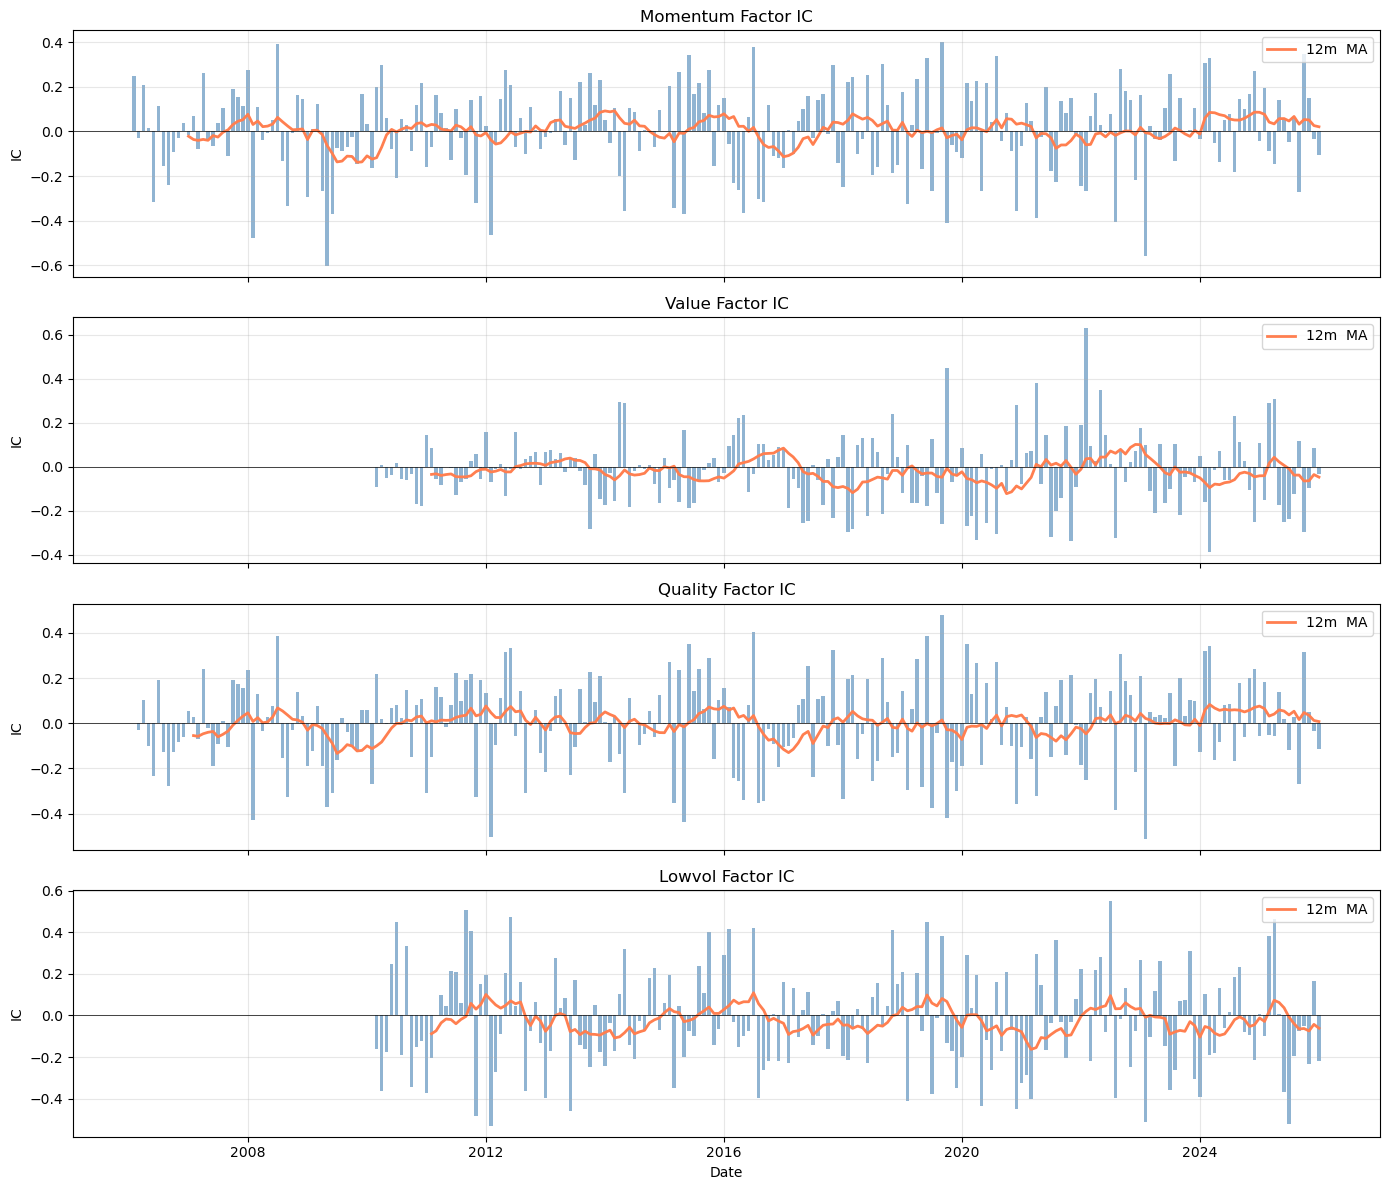

In [5]:
"""
==================================
Plot IC time series
==================================
"""
fig, axes = plt.subplots(4,1, figsize=(14,12), sharex = True)

for ax, (name, ic_series) in zip(axes, ic_results.items()):
    ax.bar(ic_series.index, ic_series.values, color='steelblue', alpha=0.6, width=20)
    ax.plot(ic_series.index, ic_series.rolling(12).mean(), color='coral', linewidth=2, label='12m  MA')
    ax.axhline(y=0, color='black', linestyle='-', linewidth=0.5)
    ax.set_ylabel('IC')
    ax.set_title(f'{name.capitalize()} Factor IC')
    ax.legend(loc='upper right')
    ax.grid(alpha=0.3)

axes[-1].set_xlabel('Date')
plt.tight_layout()
plt.savefig('../images/02_factor_diagnostics/ic_time_series.png', dpi=150, bbox_inches='tight')
plt.show()

## Subperiod IC Stability (Walk-Forward)

A positive full-sample IC can hide a fragile result. Maybe the signal worked in one window and did nothing elsewhere. Walk-forward analysis splits the sample into non-overlapping windows and recomputes the diagnostics in each one.

This is not parameter tuning. It is just a stability check: does the sign and size of the signal look similar across regimes, or is the full-sample average doing too much storytelling?

In [6]:
"""
==================================
Subperiod IC stability (walk-forward)
==================================
"""
windows = [(2006,2011), (2011,2016),(2016,2021),(2021,2026)]
subperiod_results = []

for name in factor_dict:
    ic = ic_results[name]
    for start, end in windows:
        mask = (ic.index.year >= start) & (ic.index.year < end)
        sub = ic[mask].dropna()
        if len(sub) < 12:
            continue
        subperiod_results.append({
            'factor': name,
            'period': f'{start}-{end}',
            'mean_ic': sub.mean(),
            'std_ic': sub.std(),
            'ir': sub.mean() / sub.std() * np.sqrt(12) if sub.std() > 0 else np.nan,
            'n': len(sub),
            'pct_positive': (sub > 0).mean()
        })

df_subperiod = pd.DataFrame(subperiod_results)

# Pivot for display
pivot_ic = df_subperiod.pivot(index='factor', columns='period', values='mean_ic')
pivot_ir = df_subperiod.pivot(index='factor', columns='period', values='ir')
pivot_pct = df_subperiod.pivot(index='factor', columns='period', values='pct_positive')

print("Mean IC by Subperiod\n")
display(pivot_ic.round(4))

print("\n Information Ratio by Subperiod\n")
display(pivot_ir.round(3))

print("\n % Months with Positive IC\n")
display((pivot_pct * 100).round(1))

Mean IC by Subperiod



period,2006-2011,2011-2016,2016-2021,2021-2026
factor,,,,
lowvol,NaN,-0.0029,-0.0361,-0.0295
momentum,-0.0131,0.0276,-0.0079,0.0174
quality,-0.0287,0.0258,-0.0258,0.0183
value,NaN,-0.0179,-0.0331,-0.0095



 Information Ratio by Subperiod



period,2006-2011,2011-2016,2016-2021,2021-2026
factor,,,,
lowvol,NaN,-0.043,-0.560,-0.420
momentum,-0.237,0.547,-0.130,0.325
quality,-0.593,0.461,-0.390,0.353
value,NaN,-0.576,-0.676,-0.170



 % Months with Positive IC



period,2006-2011,2011-2016,2016-2021,2021-2026
factor,,,,
lowvol,NaN,51.7,43.3,41.7
momentum,48.3,61.7,45.0,58.3
quality,47.5,63.3,43.3,60.0
value,NaN,40.0,46.7,48.3


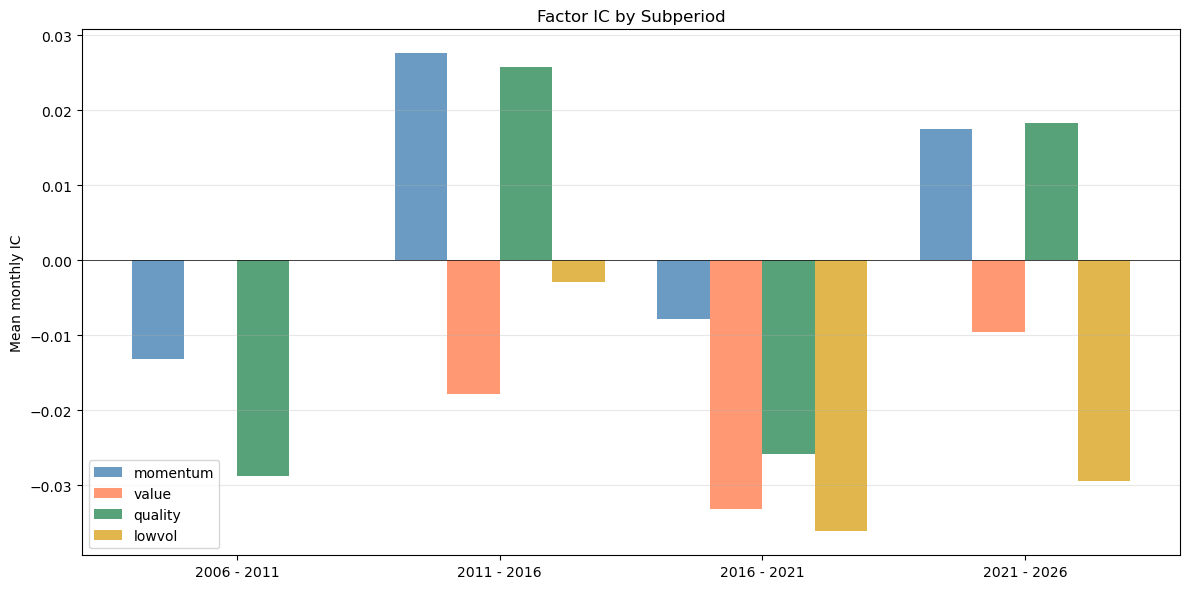

In [7]:
# Plot subperiod IC
fig,ax = plt.subplots(figsize=(12,6))
x = np.arange(len(windows))
width = 0.2
colors = ['steelblue', 'coral', 'seagreen', 'goldenrod']
for i, name in enumerate(factor_dict):
    vals = [pivot_ic.loc[name, f'{s}-{e}'] if f'{s}-{e}' in pivot_ic.columns else 0 for s, e in windows]
    ax.bar(x + i * width, vals, width, label=name, color=colors[i], alpha=0.8)

ax.set_xticks(x + width * 1.5)
ax.set_xticklabels([f'{s} - {e}' for s,e in windows])
ax.set_ylabel('Mean monthly IC')
ax.set_title('Factor IC by Subperiod')
ax.axhline(y=0, color='black', linewidth=0.5)
ax.legend()
ax.grid(alpha=0.3, axis='y')

plt.tight_layout()
plt.savefig('../images/02_factor_diagnostics/ic_subperiod.png', dpi=150, bbox_inches='tight')
plt.show()

## Factor Decay

A one-month IC tells us whether a signal is useful right after it is measured. IC decay asks how long that usefulness lasts.

For a horizon $h$, we compare today's factor ranks to cumulative returns over the next $h$ months. If the IC stays positive as $h$ grows, the signal is slow-moving and may tolerate less frequent rebalancing. If it drops quickly, the signal needs faster trading and is more exposed to transaction costs.

In vector language, a slow signal keeps a small angle between $\mathrm{rank}(f_t)$ and $\mathrm{rank}(r_{t:t+h})$ for several horizons. A fast signal loses that alignment quickly.

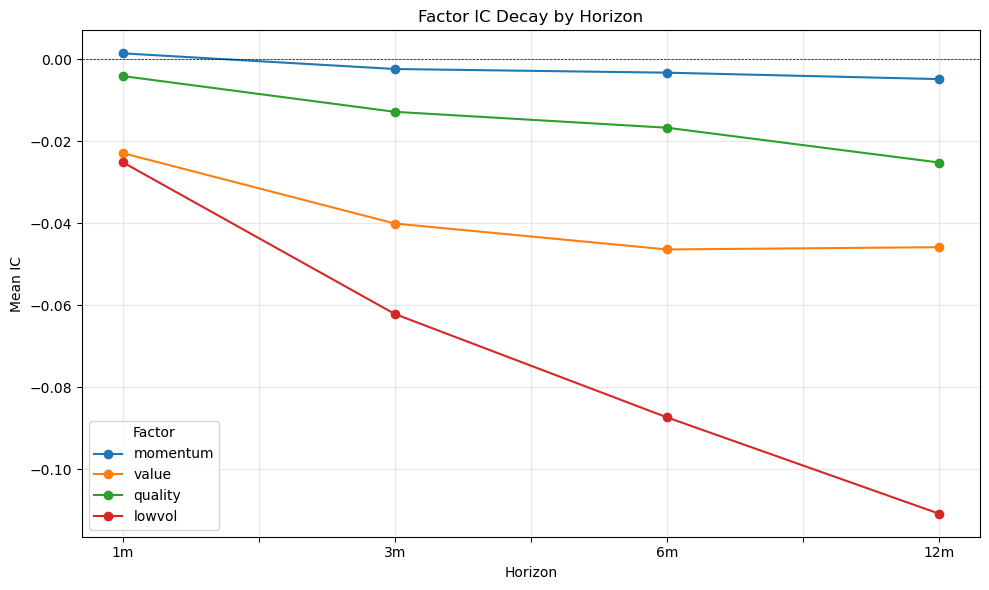

,1m,3m,6m,12m
momentum,0.0015,-0.0023,-0.0032,-0.0048
value,-0.0229,-0.0400,-0.0463,-0.0458
quality,-0.0041,-0.0128,-0.0167,-0.0251
lowvol,-0.0251,-0.0621,-0.0873,-0.1108


In [8]:
"""
==================================
IC decay at horizons 1, 3, 6, 12 months
==================================
"""
horizons = [1,3,6,12]
decay_results = {}

for name, df_f in factor_dict.items():
    decay_results[name] = []
    for h in horizons:
        # Forward returns at horizon h
        fwd_returns = df_returns.rolling(h).sum().shift(-h)
        ic_series = compute_monthly_ic(df_f, fwd_returns)
        decay_results[name].append(ic_series.mean())

df_decay = pd.DataFrame(decay_results, index=[f'{h}m' for h in horizons]).T

fig,ax = plt.subplots(figsize=(10,6))
df_decay.T.plot(ax=ax, marker='o')
ax.set_xlabel('Horizon')
ax.set_ylabel('Mean IC')
ax.set_title('Factor IC Decay by Horizon')
ax.axhline(y=0, color='black', linestyle='--', linewidth=0.5)
ax.grid(alpha=0.3)
ax.legend(title='Factor')

plt.tight_layout()
plt.savefig('../images/02_factor_diagnostics/ic_decay.png', dpi=150, bbox_inches='tight')
plt.show()

display(df_decay.round(4))

## Turnover via Rank Autocorrelation

A factor that re-ranks the universe every month will produce high turnover, and this contributes to lowering net returns after transaction costs.

**Rank autocorrelation** is the correlation between this month's factor rank vector and last month's. If the rank vector barely changes (autocorrelation $\approx$ 1), the portfolio barely trades. If it changes a lot (autocorrelation $\approx$ 0), turnover is high. In linear algebraic terms, the rank vector at $t$ is nearly parallel to the rank vector at $t-1$ for stable factors, and nearly orthogonal for unstable ones.

momentum: rank autocorr = 0.888, turnover proxy = 0.112


value: rank autocorr = 0.977, turnover proxy = 0.023


quality: rank autocorr = 0.898, turnover proxy = 0.102


lowvol: rank autocorr = 0.997, turnover proxy = 0.003


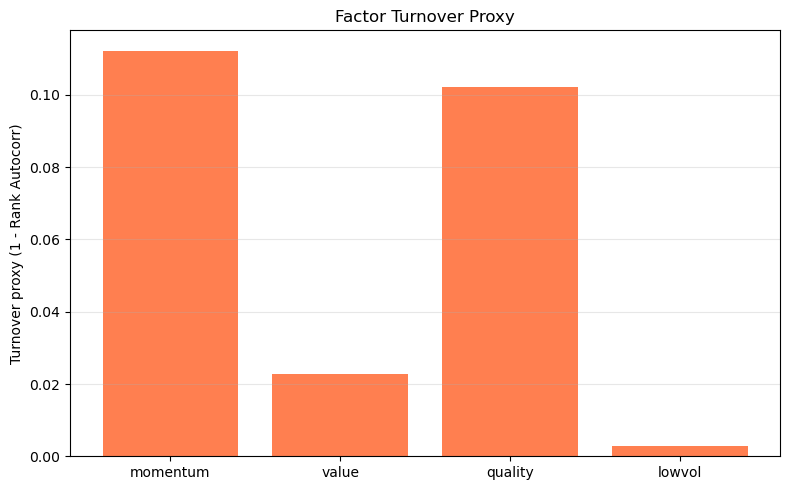

In [9]:
"""
==================================
Rank autocorrelation as turnover proxy
==================================
"""
def rank_autocorrelation(factor_df, lag=1):
    """Averages cross-sectional rank correlation between t and t-lag."""
    common_dates = factor_df.index[:-lag]
    autocorr = []
    for date in common_dates:
        f_now = factor_df.loc[date]
        f_lag = factor_df.loc[factor_df.index[factor_df.index.get_loc(date) + lag]]
        mask = f_now.notna() & f_lag.notna()
        if mask.sum() < 20:
            continue
        rho,_ = spearmanr(f_now[mask], f_lag[mask])
        autocorr.append(rho)
    return np.mean(autocorr)

turnover_proxy = {}
for name, df_f in factor_dict.items():
    rho = rank_autocorrelation(df_f, lag=1)
    turnover_proxy[name] = rho
    # Rough turnover estimate: 1 - rho
    print(f"{name}: rank autocorr = {rho:.3f}, turnover proxy = {1 - rho:.3f}")

fig,ax = plt.subplots(figsize=(8,5))
ax.bar(turnover_proxy.keys(), [1-v for v in turnover_proxy.values()], color='coral')
ax.set_ylabel('Turnover proxy (1 - Rank Autocorr)')
ax.set_title('Factor Turnover Proxy')
ax.grid(alpha=0.3, axis='y')

plt.tight_layout()
plt.savefig('../images/02_factor_diagnostics/turnover_proxy.png', dpi=150, bbox_inches='tight')
plt.show()

## Cross-Factor Correlations

The cross-factor correlation matrix asks whether the factors are actually different from each other.

If we stack factor vectors into a matrix

$$F_t = [f_{1,t}, f_{2,t}, f_{3,t}, f_{4,t}],$$

then a Gram matrix has entries

$$G_{ij}=\langle f_{i,t}, f_{j,t}\rangle.$$

Because our factors are centered ranks, these inner products are proportional to correlations. A high off-diagonal entry means two factors are nearly collinear and probably redundant. A value near zero means the factors are closer to orthogonal and may diversify each other.

This matters because combining four factor names is not the same as combining four independent sources of information.

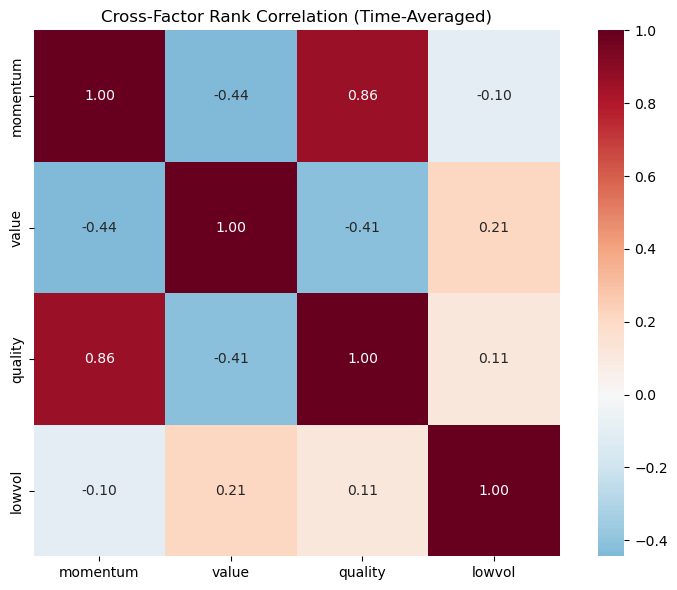

,momentum,value,quality,lowvol
momentum,1.000,-0.444,0.860,-0.104
value,-0.444,1.000,-0.412,0.210
quality,0.860,-0.412,1.000,0.109
lowvol,-0.104,0.210,0.109,1.000


In [10]:
"""
==================================
Cross-factor rank correlation (time-averaged)
==================================
"""
factor_names = list(factor_dict.keys())
corr_matrix = np.zeros((len(factor_names), len(factor_names)))

for i, name_i in enumerate(factor_names):
    for j, name_j in enumerate(factor_names):
        if i == j:
            corr_matrix[i,j] = 1.0
            continue
        df_i = factor_dict[name_i]
        df_j = factor_dict[name_j]
        common_dates = df_i.index.intersection(df_j.index)

        corrs = []
        for date in common_dates:
            a = df_i.loc[date]
            b = df_j.loc[date]
            mask = a.notna() & b.notna()
            if mask.sum() < 20:
                continue
            rho, _ = spearmanr(a[mask], b[mask])
            corrs.append(rho)
        corr_matrix[i,j] = np.mean(corrs)

df_corr = pd.DataFrame(corr_matrix, index=factor_names, columns=factor_names)

fig,ax = plt.subplots(figsize=(8,6))
sns.heatmap(df_corr, annot=True, fmt='.2f', cmap='RdBu_r', center=0, ax=ax, square=True)
ax.set_title('Cross-Factor Rank Correlation (Time-Averaged)')

plt.tight_layout()
plt.savefig('../images/02_factor_diagnostics/factor_correlation.png', dpi=150, bbox_inches='tight')
plt.show()

display(df_corr.round(3))

In [11]:
"""
==================================
Save factor exposures and IC results
==================================
"""
for name, df_f in factor_dict.items():
    df_f.to_csv(f'../data/processed/factor_{name}.csv')

df_ic.to_csv('../data/processed/ic_monthly.csv')
df_decay.to_csv('../data/processed/ic_decay.csv')
df_corr.to_csv('../data/processed/factor_correlation.csv')

print("Saved factor exposures, IC series, decay, and correlation matrix.")

Saved factor exposures, IC series, decay, and correlation matrix.


## Conclusion

The diagnostics point to one usable signal in this price-only setup: **momentum**. Its full-sample IC is small but positive, and it is more stable than the other proxies. That is enough to justify carrying it forward, but not enough to pretend we have found a large or universal edge.

The other three proxies are mostly useful as negative examples:

- **Value:** the inverse 60-month return proxy behaves more like a bet against long-term winners than a true value measure. Without fundamentals, it cannot distinguish cheapness from price drift.
- **Quality:** the rolling Sharpe proxy is highly correlated with momentum, so it is not adding much independent information.
- **Low-volatility:** the signal is stable, but in this sample it points the wrong way.

The factor correlation matrix explains why a naive composite is unlikely to help. Momentum and quality are close to the same direction, value is partly the opposite direction, and low-vol is more independent but has negative IC. The next notebook builds the signal we will actually trade: sector-neutralized momentum.